<style>       
    hr{
        height: 4px;
        background-color: rgb(247,148,9);
        border: none;
    }
</style>
<div style="color=white;
           display:fill;
           border-radius:5px;
           background-color:rgb(34,41,49)">
<hr>

<div style="clear: both; font-size: 30pt; font-weight: bold;">
    Interpolation and sampling
</div>
<hr>
</div>

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as wg
import IPython
import scipy.signal as sp
from scipy.io import wavfile

plt.rcParams["figure.figsize"] = (12,3)

# Interpolation

Here's a function to generate $N$ samples of a discrete-time sinusoid with frequency $\omega_0 = \pi / 4$

In [3]:
def mycos(N):
    return np.cos(np.pi / 4 * np.arange(N))

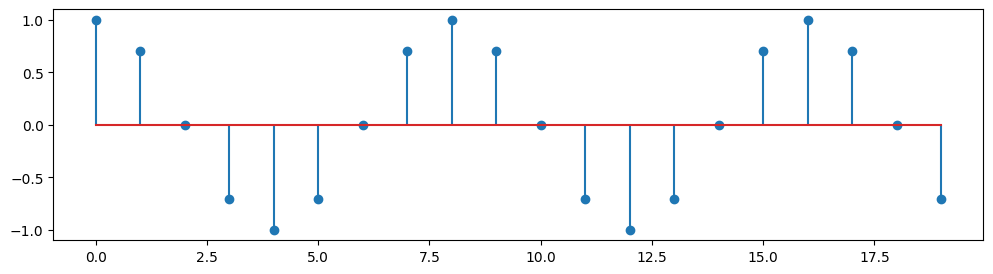

In [4]:
plt.stem(mycos(20));

Let's play the signal using the soundcard of your PC; the interpolation frequency $F_s$ determines the continuous-time frequency as 

$$
    f_0 = \frac{\omega_c}{2\pi}F_s = \frac{F_s}{8} \text{~Hz}
$$

E.g., for $F_s = 4000$ Hz, $f_0 = 500$ Hz.

In [12]:
Fs = 16000
IPython.display.Audio(mycos(2 * Fs), rate=Fs)

# Aliasing of sinusoids

In [6]:
Fs = 4000

for f in np.arange(400, 3000, 400):
    if f == Fs / 2:
        continue
    x = np.cos(2 * np.pi * f / Fs * np.arange(Fs))
    print(f'f={f}, w/pi={2*f/Fs}, fo={f - Fs*np.floor(f/Fs + 0.5)}')
    display(IPython.display.Audio(x, rate=Fs))

f=400, w/pi=0.2, fo=400.0


f=800, w/pi=0.4, fo=800.0


f=1200, w/pi=0.6, fo=1200.0


f=1600, w/pi=0.8, fo=1600.0


f=2400, w/pi=1.2, fo=-1600.0


f=2800, w/pi=1.4, fo=-1200.0


### Exercise

Complete the code below so that it plots the samples of the function $x_c(t)$ at a sampling rate $F_s$. Once you have that, plot the result for $F_s = 100$, $F_s = 20$, $F_s = 10$, and $F_s = 9.9$.

For $F_s = 9.9$ extend the range of the plot and look at the pattern of the samples; what can you say?

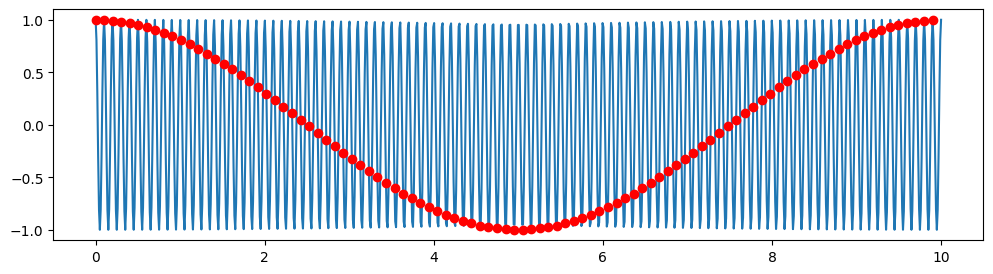

In [2]:
def x_c(t, f0=10):
    return np.cos(2 * np.pi * f0 * t)

T = 10
t = np.linspace(0, T, 1000)
plt.plot(t, x_c(t))

Fs = 9.9
tn = np.arange(0, T, 1/Fs)
plt.plot(tn, x_c(tn), 'ro');


# Aliasing of audio signals

The frequency folding caused by too low a sampling rate is particularly disruptive when it comes to audio signals. 

In [7]:
Fs_audio, x_audio = wavfile.read('data/music.wav')
IPython.display.Audio(x_audio, rate=Fs_audio)

In [8]:
print(Fs_audio)

16000


In [9]:
K = 5

IPython.display.Audio(x_audio[::K], rate=Fs_audio/K)

In [10]:
x_f = sp.lfilter(*sp.butter(8, 0.5 / K), x_audio)
IPython.display.Audio(x_f[::K], rate=Fs_audio/K)

## Aliasing in images

aliasing is particularly noticeable when downsampling a picture that contains high-frequency elements such as a striped pattern. That's why it's important to lowpass filter an image before reducing its size

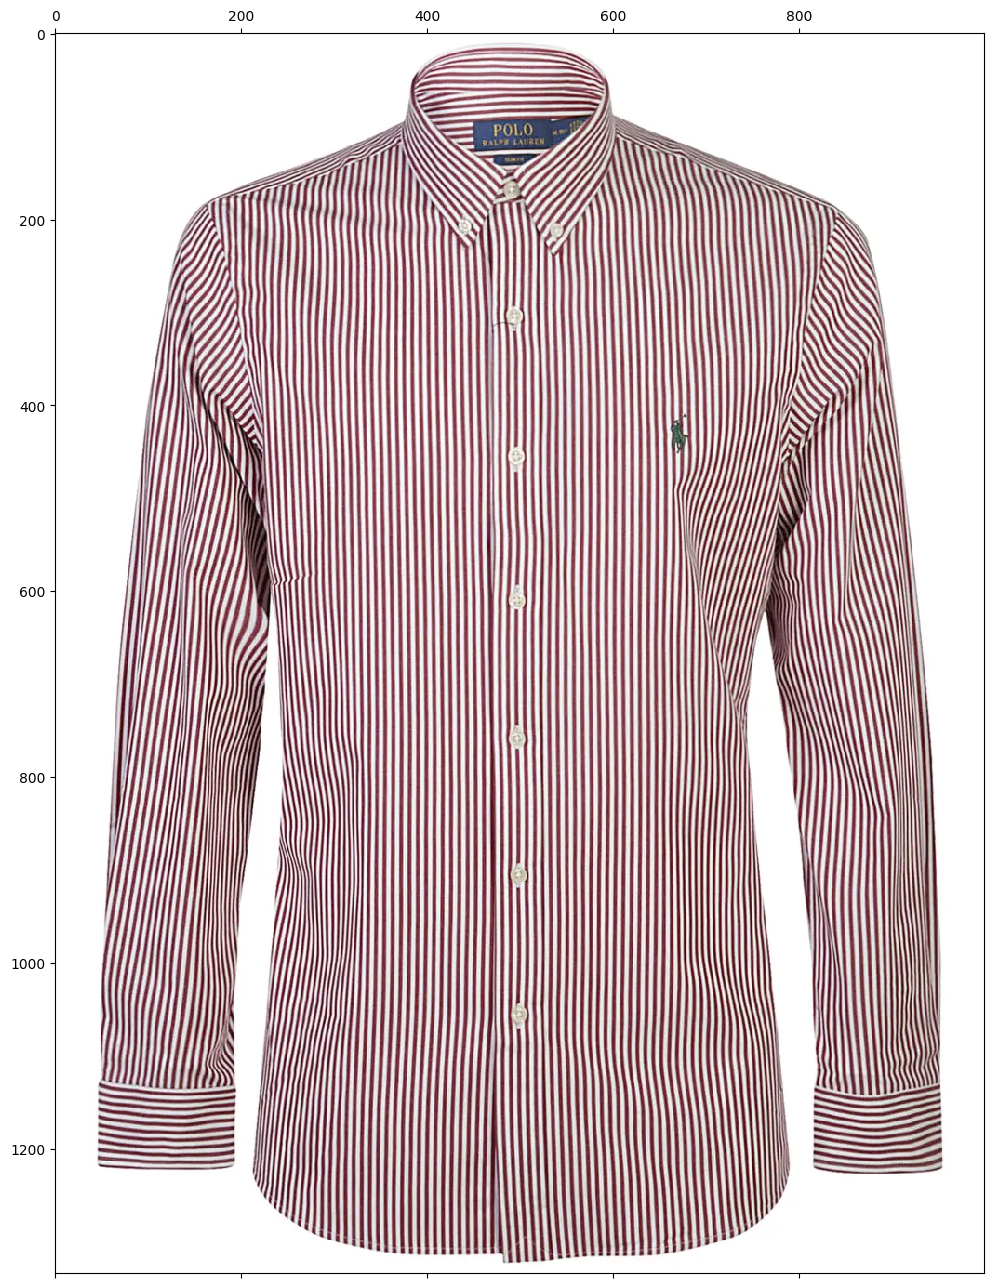

In [40]:
plt.rcParams["figure.figsize"] = (30, 30)

shirt = np.array(plt.imread('img/shirt2.png'))
plt.matshow(shirt);

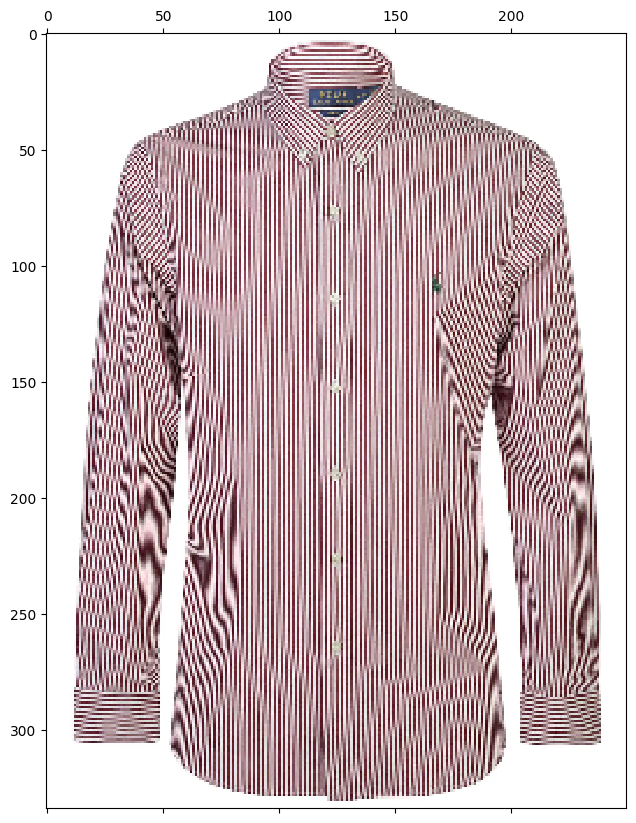

In [41]:
plt.rcParams["figure.figsize"] = (10, 10)
plt.matshow(shirt[::4,::4]);

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.009999997306316835..1.0000001033506887].


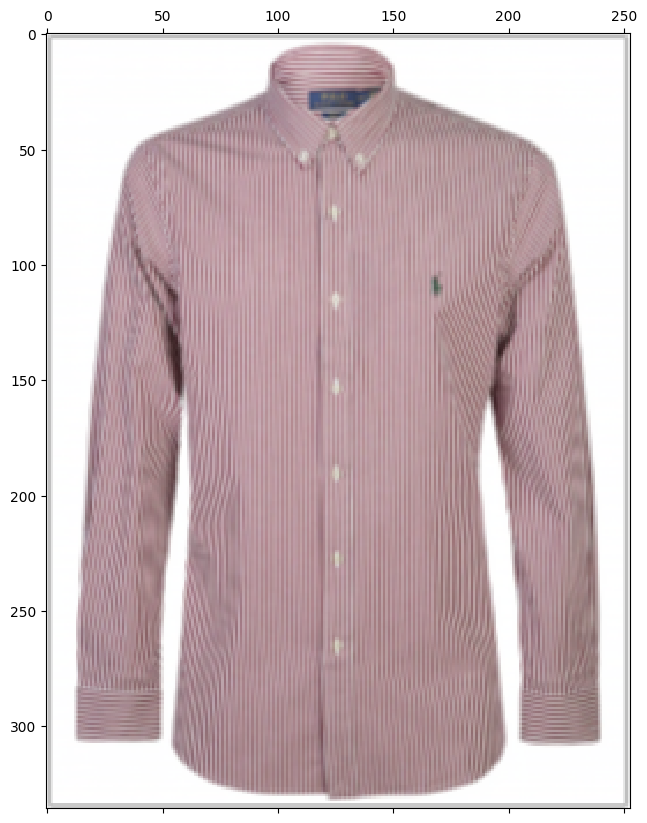

In [44]:
# let's use a simple moving average filter before downsampling:

N = 10
plt.matshow(sp.convolve(shirt, np.ones((N,N,1)) / (N*N))[::4,::4]);